In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.ppm_features import ppm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
209,2025-26,201145,Jeff Green,Jeff,1610612745,HOU,Houston Rockets,22501194,2026-04-12T00:00:00,HOU vs. MEM,W,24.183333,2,8,0.250,0,4,0.00,2,2,1.000,2,3,5,1,3,1,1,0,2,1,6,7,16.5,0,0,16.0,1,24:11,1,103.9,105.5,105.5,86.1,91.1,91.1,17.8,14.4,14.4,0.059,0.33,7.7,0.063,0.100,0.081,23.1,23.3,0.250,0.338,0.174,0.181,114.13,110.16,91.80,110.16,0.016,55,2.0,8.0,48,105,0.457,14,49,0.286,22,30,0.733,21,43,64,23,11.0,10,8,6,10,24,132,31.0,122.0,128.2,94.9,98.1,27.1,30.1,0.479,2.09,14.9,0.452,0.821,0.627,0.107,0.524,0.558,107.3,103.0,85.83,103,0.642,1610612763,MEM,Memphis Grizzlies,39,95,0.411,13,49,0.265,10,10,1.000,6,31,37,23,13.0,8,6,8,24,10,101,-31.0,94.9,98.1,122.0,128.2,-27.1,-30.1,0.590,1.77,16.9,0.179,0.548,0.373,0.126,0.479,0.508,107.3,103.0,85.83,103,0.358,NaN,PF,39.0,0
210,2025-26,1631342,Daeqwon Plowden,Daeqwon,1610612758,SAC,Sacramento Kings,22501200,2026-04-12T00:00:00,SAC @ POR,L,22.200000,2,5,0.400,1,4,0.25,3,3,1.000,0,1,1,2,3,0,2,0,4,1,8,-8,15.2,0,0,16.0,1,22:12,1,118.2,114.6,114.6,127.2,134.0,134.0,-9.0,-19.5,-19.5,0.100,0.67,18.2,0.000,0.034,0.022,27.3,26.5,0.500,0.633,0.173,0.184,103.83,102.70,85.59,102.70,0.017,48,2.0,5.0,40,83,0.482,7,21,0.333,23,31,0.742,15,32,47,24,17.0,7,8,3,18,21,110,-12.0,111.5,112.2,120.1,123.2,-8.6,-11.0,0.600,1.41,17.3,0.370,0.600,0.495,0.173,0.524,0.569,100.1,98.5,82.08,98,0.478,1610612757,POR,Portland Trail Blazers,47,101,0.465,16,46,0.348,12,15,0.800,18,28,46,28,12.0,9,3,8,21,18,122,12.0,120.1,123.2,111.5,112.2,8.6,11.0,0.596,2.33,18.8,0.400,0.630,0.505,0.121,0.545,0.567,100.1,98.5,82.08,99,0.522,F,SG,27.0,1
211,2025-26,1630286,Trevon Scott,Trevon,1610612751,BKN,Brooklyn Nets,22501192,2026-04-12T00:00:00,BKN @ TOR,L,26.050000,3,8,0.375,2,5,0.40,0,0,0.000,1,2,3,1,2,1,0,0,2,0,8,-17,14.1,0,0,16.0,1,26:03,1,104.8,109.3,109.3,137.8,135.7,135.7,-32.9,-26.5,-26.5,0.053,0.50,9.1,0.038,0.125,0.071,18.2,18.2,0.500,0.500,0.164,0.161,102.67,101.34,84.45,101.34,0.027,54,3.0,8.0,35,86,0.407,9,34,0.265,22,29,0.759,13,25,38,21,16.0,9,0,8,27,20,101,-35.0,99.3,101.0,136.3,136.0,-37.1,-35.0,0.600,1.31,15.6,0.255,0.844,0.471,0.160,0.459,0.511,100.8,100.0,83.33,100,0.277,1610612761,TOR,Toronto Raptors,51,80,0.638,12,27,0.444,22,29,0.759,3,40,43,36,10.0,9,8,0,20,27,136,35.0,136.3,136.0,99.3,101.0,37.1,35.0,0.706,3.60,25.5,0.156,0.745,0.529,0.100,0.713,0.733,100.8,100.0,83.33,100,0.723,C,NaN,NaN,1
204,2025-26,1629020,Jarred Vande

In [3]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["PTS_PER_MIN"] = df["PTS"] / df["MIN"].replace(0, np.nan)
    df['PTS_PER_POSS'] = df['PTS'] / df['POSS'].replace(0, np.nan)
    df['POSS_PER_MIN'] = df['POSS'] / df['MIN'].replace(0, np.nan)
    df['FGA_PER_MIN'] = df['FGA'] / df['MIN'].replace(0, np.nan)
    df['3PA_PER_MIN'] = df['FG3A'] / df['MIN'].replace(0, np.nan)
    df['FTA_PER_MIN'] = df['FTA'] / df['MIN'].replace(0, np.nan)
    # df['STARTING'] = df['START_POSITION'].notna().astype(int)
    # df['BAYES_PPM_PROJ'] = apply_bayesian_ppm(df)
    df = ppm_features(df)
    df['TEAM_PTS_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TS_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TRUE_USG_L10'] = df['POSS_roll10'] / df['TEAM_POSS_roll10']

    df['PPM_MOMENTUM'] = df['PTS_PER_MIN_5_ewm'] - df['PTS_PER_MIN_10_ewm']

    df['POSS_DIFF_L10'] = df['POSS_roll10'] - df['TEAM_POSS_roll10']
    df['TS_PCT_DELTA'] = df['TS_PCT_roll10'] - df['TEAM_TS_PCT_roll10']

    df['TS_PCT_X_USG_PCT'] = df['TS_PCT_season_avg'] * df['USG_PCT_season_avg']
    df['USG_X_OPP_DRTG_L10'] = df['USG_PCT_10_ewm'] * df['OPP_DEF_RATING_roll10']
    df['PPM_SEASON_AVG_X_USG_PCT_L10'] = df['PTS_PER_MIN_season_avg'] * df['USG_PCT_roll10']
    df['PPM_SEASON_AVG_X_OPP_DRTG_L10'] = df['PTS_PER_MIN_season_avg'] * df['OPP_DEF_RATING_roll10']
    df['FGA_PER_MIN_X_OPP_DRTG_L10'] = df['FGA_PER_MIN_season_avg'] * df['OPP_DEF_RATING_roll10']
    df['FTA_PER_MIN_X_OPP_DRTG_L10'] = df['FTA_PER_MIN_season_avg'] * df['OPP_DEF_RATING_roll10']
    df['3PA_PER_MIN_X_OPP_DRTG_L10'] = df['3PA_PER_MIN_season_avg'] * df['OPP_DEF_RATING_roll10']
    df['TOP_STAR_X_OPP_POSS_L10'] = df['IS_TOP_STAR'] * df['OPP_POSS_roll10']
    df['MIN_X_USG_PCT_L10'] = df['MIN_10_ewm'] * df['USG_PCT_10_ewm']
    df['ACTIVE_STARS_X_USG_PCT_L10'] = df['ACTIVE_STARS_COUNT'] * df['USG_PCT_10_ewm']
    df['TEAM_USG_RANK_X_USG_PCT_L10'] = df['TEAM_USG_RANK_L10'] * df['USG_PCT_10_ewm']
    df['PPM_SEASON_AVG_X_MIN_L10'] = df['PTS_PER_MIN_season_avg'] * df['MIN_10_ewm']

    player_stats = df.groupby('PLAYER_ID')['PTS_PER_MIN']
    df['PPM_SEASON_STD'] = player_stats.transform(lambda x: x.expanding().std().shift(1))
    df['PPM_SEASON_MEAN'] = player_stats.transform(lambda x: x.expanding().mean().shift(1))
    df['PPM_ROLE_Z_SCORE'] = (df['PTS_PER_MIN_10_ewm'] - df['PPM_SEASON_MEAN']) / df['PPM_SEASON_STD']

    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)

# # Build player tier labels from training data only
# player_stats = (
#     df.groupby("PLAYER_NAME")
#     .agg(
#         mean_ppm     = ("PTS_PER_MIN", "mean"),
#         mean_usg     = ("USG_PCT", "mean"),
#         mean_minutes = ("MIN", "mean"),          # add MIN to PPM_FEATURES if not there
#         games        = ("PTS_PER_MIN", "count"),
#     )
#     .query("games >= 20")                        # ignore small samples
# )

# # Star = top 15% PPM AND averaging meaningful minutes
# star_mask    = (
#     (player_stats["mean_ppm"]     >= player_stats["mean_ppm"].quantile(0.85)) &
#     (player_stats["mean_minutes"] >= 25) &
#     (player_stats["mean_usg"]     >= player_stats["mean_usg"].quantile(0.85))
# )

# star_players    = set(player_stats[star_mask].index)
# role_players    = set(player_stats[~star_mask].index)

# print(f"Stars: {len(star_players)} | Role players: {len(role_players)}")
# print(sorted(star_players))

In [ ]:
PPM_FEATURES = [
    'PTS_PER_MIN_10_ewm',
    'FGA_PER_MIN_10_ewm',
    'FTA_PER_MIN_10_ewm',
    'USG_PCT_10_ewm',
    'ACTIVE_STARS_COUNT',
    'TEAM_MIN_RANK_L10',
    'OPP_POSS_roll10',

    # Interactions
    'TOP_STAR_X_OPP_POSS_L10',
    'PPM_SEASON_AVG_X_OPP_DRTG_L10',
    'FGA_PER_MIN_X_OPP_DRTG_L10',
    'FTA_PER_MIN_X_OPP_DRTG_L10',
    '3PA_PER_MIN_X_OPP_DRTG_L10',
    'ACTIVE_STARS_X_USG_PCT_L10',
    'TS_PCT_X_USG_PCT',
    'PPM_SEASON_AVG_X_MIN_L10',
]

In [5]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = df[PPM_FEATURES + ["PTS_PER_MIN", "GAME_DATE", "PLAYER_NAME", "GAME_ID"]].dropna().sort_values("GAME_DATE").reset_index(drop=True)
print(ppm_df.shape)

# ── 2. Walk-forward folds ─────────────────────────────────────────────────────
N_FOLDS   = 4
min_train = int(len(ppm_df) * 0.50)
fold_size = (len(ppm_df) - min_train) // N_FOLDS

fold_results = []

all_results = []
for fold in range(N_FOLDS):
    train_end = min_train + fold * fold_size
    val_end   = train_end + fold_size

    train_idx = ppm_df.index[:train_end]
    val_idx   = ppm_df.index[train_end:val_end]

    X_train_f = ppm_df.loc[train_idx, PPM_FEATURES]
    X_val_f   = ppm_df.loc[val_idx,   PPM_FEATURES]
    y_train_f = ppm_df.loc[train_idx, "PTS_PER_MIN"]
    y_val_f   = ppm_df.loc[val_idx,   "PTS_PER_MIN"]

    # ── 3. Quantile models ────────────────────────────────────────────────────
    quantiles       = [0.10, 0.50, 0.90]
    quantile_models = {}
    quantile_preds  = {}

    for q in quantiles:
        xgb_q = XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=q,
            n_estimators=1378,
            max_depth=6,
            learning_rate=0.012114761889717784,
            subsample=0.80,
            colsample_bytree=0.6610449450867388,
            reg_alpha=0.15,
            reg_lambda=0.7792871271834488,
            min_child_weight=2,
            n_jobs=-1,
            random_state=42,
            early_stopping_rounds=50,
        )
        xgb_q.fit(
            X_train_f, y_train_f,
            eval_set=[(X_val_f, y_val_f)],
            verbose=False,
        )
        quantile_models[f"q_{q:.2f}"] = xgb_q
        quantile_preds[f"q_{q:.2f}"]  = xgb_q.predict(X_val_f)

    # ── 4. Fold diagnostics ───────────────────────────────────────────────────
    actual   = y_val_f.values
    lower    = quantile_preds["q_0.10"]
    median   = quantile_preds["q_0.50"]
    upper    = quantile_preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))

    fold_metrics = {
        "fold":           fold + 1,
        "train_rows":     len(train_idx),
        "val_rows":       len(val_idx),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {f"q_{q:.2f}": quantile_models[f"q_{q:.2f}"].best_iteration
                           for q in quantiles},
    }
    fold_results.append(fold_metrics)

    fold_df = ppm_df.loc[val_idx, ["PLAYER_NAME", "GAME_ID", "GAME_DATE", "PTS_PER_MIN"]].copy()
    fold_df["PRED_Q10"] = quantile_preds["q_0.10"]
    fold_df["PRED_Q50"] = quantile_preds["q_0.50"]
    fold_df["PRED_Q90"] = quantile_preds["q_0.90"]
    all_results.append(fold_df)

    print(f"Fold {fold+1} | MAE: {fold_metrics['mae']:.3f} | "
          f"R²: {fold_metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%} | "
          f"Best iters: {fold_metrics['best_iters']}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
maes      = [f["mae"]            for f in fold_results]
r2s       = [f["r2"]             for f in fold_results]
coverages = [f["coverage_80pct"] for f in fold_results]

print(f"\n{'─'*55}")
print(f"Walk-Forward Summary ({N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f} ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(coverages):.1%} ± {np.std(coverages):.1%}  (target ~80%)")

(84032, 21)
Fold 1 | MAE: 0.181 | R²: 0.231 | 80% Coverage: 75.5% | Best iters: {'q_0.10': 387, 'q_0.50': 396, 'q_0.90': 350}
Fold 2 | MAE: 0.187 | R²: 0.169 | 80% Coverage: 77.2% | Best iters: {'q_0.10': 547, 'q_0.50': 357, 'q_0.90': 265}
Fold 3 | MAE: 0.181 | R²: 0.233 | 80% Coverage: 77.0% | Best iters: {'q_0.10': 496, 'q_0.50': 415, 'q_0.90': 375}
Fold 4 | MAE: 0.189 | R²: 0.197 | 80% Coverage: 77.2% | Best iters: {'q_0.10': 606, 'q_0.50': 386, 'q_0.90': 350}

───────────────────────────────────────────────────────
Walk-Forward Summary (4 folds)
  MAE      : 0.185 ± 0.004
  R²       : 0.208 ± 0.026
  Coverage : 76.7% ± 0.7%  (target ~80%)


In [9]:
results_df = pd.concat(all_results).rename(columns={"PTS_PER_MIN": "ACTUAL_PPM"})
results_df["ERROR"]    = results_df["ACTUAL_PPM"] - results_df["PRED_Q50"]
results_df["IN_RANGE"] = (
    (results_df["ACTUAL_PPM"] >= results_df["PRED_Q10"]) &
    (results_df["ACTUAL_PPM"] <= results_df["PRED_Q90"])
)
results_df = results_df.sort_values("GAME_DATE").reset_index(drop=True)
print(f"Shai Gilgeous-Alexander actual PPM: {results_df[results_df['PLAYER_NAME'] == 'Shai Gilgeous-Alexander']['ACTUAL_PPM'].mean()}")
print(f"Shai Gilgeous-Alexander predicted PPM: {results_df[results_df['PLAYER_NAME'] == 'Shai Gilgeous-Alexander']['PRED_Q50'].mean()}")
results_df[results_df['PLAYER_NAME'] == 'Shai Gilgeous-Alexander'].sample(10)


# results_df.sample(10)

Shai Gilgeous-Alexander actual PPM: 0.9587943466924547
Shai Gilgeous-Alexander predicted PPM: 0.8719910383224487


,PLAYER_NAME,GAME_ID,GAME_DATE,ACTUAL_PPM,PRED_Q10,PRED_Q50,PRED_Q90,ERROR,IN_RANGE
11129,Shai Gilgeous-Alexander,22400724,2025-02-05,1.459854,0.633757,0.912530,1.133680,0.547324,False
13008,Shai Gilgeous-Alexander,22400820,2025-02-23,0.970619,0.608728,0.900003,1.097959,0.070616,True
3610,Shai Gilgeous-Alexander,22401230,2024-12-14,0.850611,0.543920,0.779776,1.065529,0.070836,True
8062,Shai Gilgeous-Alexander,22400574,2025-01-16,1.368457,0.581223,0.850850,1.083401,0.517607,False
18844,Shai Gilgeous-Alexander,22401108,2025-04-02,0.932730,0.613913,0.926262,1.100564,0.006468,True
4100,Shai Gilgeous-Alexander,22400361,2024-12-19,0.961010,0.548143,0.776847,1.052706,0.184163,True
7178,Shai Gilgeous-Alexander,22400529,2025-01-10,1.327886,0.571475,0.787804,1.072897,0.540081,False
32257,Shai Gilgeous-Alexander,22500723,2026-02-03,0.719424,0.652943,0.945219,1.186643,-0.225794,True
20815,Shai Gilgeous-Alexander,22500194,2025-11-09,0.990940,0.609267,0.875923,1.116878,0.115017,True
39698,Shai Gilgeous-Alexander,22501089,2026-03-29,0.814775,0.611573,0.925030,1.143404,-0.110255,True


In [10]:
# Run this on your holdout results before touching betting data
def readiness_check(results_df, tier="star"):
    r = results_df.copy()
    
    mae       = r["ERROR"].abs().mean()
    coverage  = r["IN_RANGE"].mean()
    bias      = r["ERROR"].mean()          # should be near 0
    
    # Edge consistency — how often does the model's direction match reality
    r["PRED_DIR"]   = (r["PRED_Q50"] > r["ACTUAL_PPM"].mean()).astype(int)
    r["ACTUAL_DIR"] = (r["ACTUAL_PPM"] > r["ACTUAL_PPM"].mean()).astype(int)
    directional_acc = (r["PRED_DIR"] == r["ACTUAL_DIR"]).mean()

    print(f"── {tier.upper()} model readiness ──")
    print(f"  MAE             : {mae:.3f}  (target < 0.15)")
    print(f"  Coverage 80%    : {coverage:.1%}  (target 75–85%)")
    print(f"  Bias            : {bias:.4f}  (target |bias| < 0.02)")
    print(f"  Directional acc : {directional_acc:.1%}  (target > 58%)")
    
    ready = (mae < 0.15) and (0.75 <= coverage <= 0.85) and (abs(bias) < 0.02) and (directional_acc > 0.58)
    print(f"\n  Ready to backtest: {'YES' : >5}" if ready else f"\n  Ready to backtest:    NO")
    return ready

readiness_check(results_df,  tier="star")
# readiness_check(role_results_df, tier="role")

── STAR model readiness ──
  MAE             : 0.185  (target < 0.15)
  Coverage 80%    : 76.7%  (target 75–85%)
  Bias            : 0.0229  (target |bias| < 0.02)
  Directional acc : 68.6%  (target > 58%)

  Ready to backtest:    NO


np.False_

In [11]:
# Does edge size predict outcome? If large-edge bets are more accurate,
# the model has real signal even if overall MAE is slightly high
results_df["ABS_EDGE"] = results_df["ERROR"].abs()
results_df["EDGE_TIER"] = pd.qcut(results_df["ABS_EDGE"], q=4, 
                                        labels=["small", "mid", "large", "xlarge"])

print(results_df.groupby("EDGE_TIER").agg(
    mae          = ("ABS_EDGE", "mean"),
    coverage     = ("IN_RANGE", "mean"),
    directional  = ("ERROR", lambda x: (x > 0).mean()),
    count        = ("ERROR", "count")
))

                mae  coverage  directional  count
EDGE_TIER                                        
small      0.034953  0.997810     0.498096  10504
mid        0.107752  0.982864     0.478484  10504
large      0.198515  0.862719     0.467441  10504
xlarge     0.397956  0.224962     0.566260  10504


In [ ]:
# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# # ── 1. Base dataframe ─────────────────────────────────────────────────────────
# ppm_df = df[MIN_FEATURES + ["MIN", "GAME_DATE"]].dropna().sort_values("GAME_DATE").reset_index(drop=True)

# # ── 2. Walk-forward folds ─────────────────────────────────────────────────────
# N_FOLDS   = 4
# min_train = int(len(ppm_df) * 0.50)
# fold_size = (len(ppm_df) - min_train) // N_FOLDS

# folds = []
# for fold in range(N_FOLDS):
#     train_end = min_train + fold * fold_size
#     val_end   = train_end + fold_size
#     folds.append({
#         "X_train": ppm_df.loc[ppm_df.index[:train_end],          MIN_FEATURES],
#         "X_val":   ppm_df.loc[ppm_df.index[train_end:val_end],   MIN_FEATURES],
#         "y_train": ppm_df.loc[ppm_df.index[:train_end],          "MIN"],
#         "y_val":   ppm_df.loc[ppm_df.index[train_end:val_end],   "MIN"],
#     })

# # ── 3. Optuna — tune across all folds, all quantiles ─────────────────────────
# QUANTILES = [0.10, 0.50, 0.90]

# def objective(trial):
#     params = {
#         "max_depth":        trial.suggest_int("max_depth", 3, 6),
#         "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
#         "n_estimators":     trial.suggest_int("n_estimators", 800, 2000),
#         "subsample":        trial.suggest_float("subsample", 0.5, 0.9),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),
#         "reg_alpha":        trial.suggest_float("reg_alpha", 0.01, 1.0, log=True),
#         "reg_lambda":       trial.suggest_float("reg_lambda", 0.01, 1.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#     }

#     fold_maes = []
#     for fold in folds:
#         # Average MAE across all 3 quantiles per fold
#         q_maes = []
#         for q in QUANTILES:
#             model = XGBRegressor(
#                 objective="reg:quantileerror",
#                 quantile_alpha=q,
#                 early_stopping_rounds=50,
#                 n_jobs=-1,
#                 random_state=42,
#                 **params,
#             )
#             model.fit(
#                 fold["X_train"], fold["y_train"],
#                 eval_set=[(fold["X_val"], fold["y_val"])],
#                 verbose=False,
#             )
#             preds = model.predict(fold["X_val"])
#             q_maes.append(mean_absolute_error(fold["y_val"], preds))
#         fold_maes.append(np.mean(q_maes))

#     return np.mean(fold_maes)  # minimize avg MAE across folds + quantiles

# study = optuna.create_study(
#     direction="minimize",
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
# )
# study.optimize(objective, n_trials=20, show_progress_bar=True)

# best = study.best_params
# print(f"\nBest cross-fold MAE: {study.best_value:.3f}")
# print(f"Best params: {best}")

# # ── 4. Train final models with best params ────────────────────────────────────
# fold_results = []

# for i, fold in enumerate(folds):
#     quantile_models = {}
#     quantile_preds  = {}

#     for q in QUANTILES:
#         xgb_q = XGBRegressor(
#             objective="reg:quantileerror",
#             quantile_alpha=q,
#             early_stopping_rounds=50,
#             n_jobs=-1,
#             random_state=42,
#             **best,
#         )
#         xgb_q.fit(
#             fold["X_train"], fold["y_train"],
#             eval_set=[(fold["X_val"], fold["y_val"])],
#             verbose=False,
#         )
#         quantile_models[f"q_{q:.2f}"] = xgb_q
#         quantile_preds[f"q_{q:.2f}"]  = xgb_q.predict(fold["X_val"])

#     actual   = fold["y_val"].values
#     lower    = quantile_preds["q_0.10"]
#     median   = quantile_preds["q_0.50"]
#     upper    = quantile_preds["q_0.90"]
#     coverage = np.mean((actual >= lower) & (actual <= upper))

#     fold_metrics = {
#         "fold":           i + 1,
#         "mae":            mean_absolute_error(actual, median),
#         "r2":             r2_score(actual, median),
#         "coverage_80pct": coverage,
#         "best_iters":     {f"q_{q:.2f}": quantile_models[f"q_{q:.2f}"].best_iteration
#                            for q in QUANTILES},
#     }
#     fold_results.append(fold_metrics)

#     print(f"Fold {i+1} | MAE: {fold_metrics['mae']:.3f} | "
#           f"R²: {fold_metrics['r2']:.3f} | "
#           f"80% Coverage: {coverage:.1%} | "
#           f"Best iters: {fold_metrics['best_iters']}")

# # ── 5. Summary ────────────────────────────────────────────────────────────────
# maes      = [f["mae"]            for f in fold_results]
# r2s       = [f["r2"]             for f in fold_results]
# coverages = [f["coverage_80pct"] for f in fold_results]

# print(f"\n{'─'*55}")
# print(f"Walk-Forward Summary ({N_FOLDS} folds)")
# print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
# print(f"  R²       : {np.mean(r2s):.3f} ± {np.std(r2s):.3f}")
# print(f"  Coverage : {np.mean(coverages):.1%} ± {np.std(coverages):.1%}  (target ~80%)")

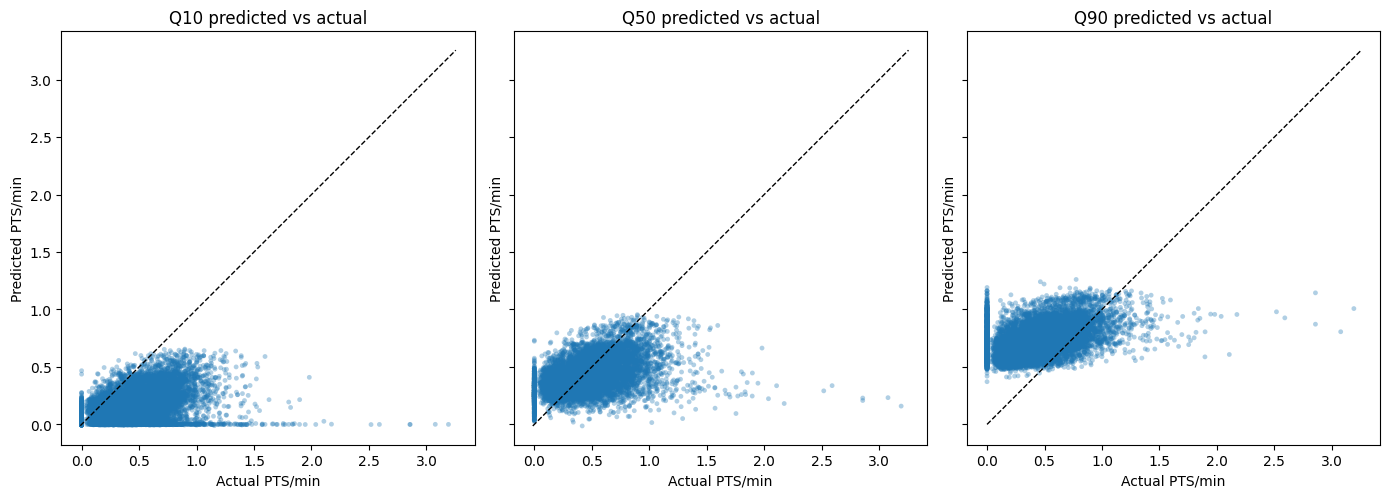

Q10 P(y ≤ pred): 0.1150990099009901
Q50 P(y ≤ pred): 0.48267326732673266
Q90 P(y ≤ pred): 0.8866146230007617
Coverage (10–90 interval): 77.15%


In [12]:
import matplotlib.pyplot as plt

y_true = y_val_f
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual PTS/min")
    ax.set_ylabel("Predicted PTS/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%


── q_0.10 ──


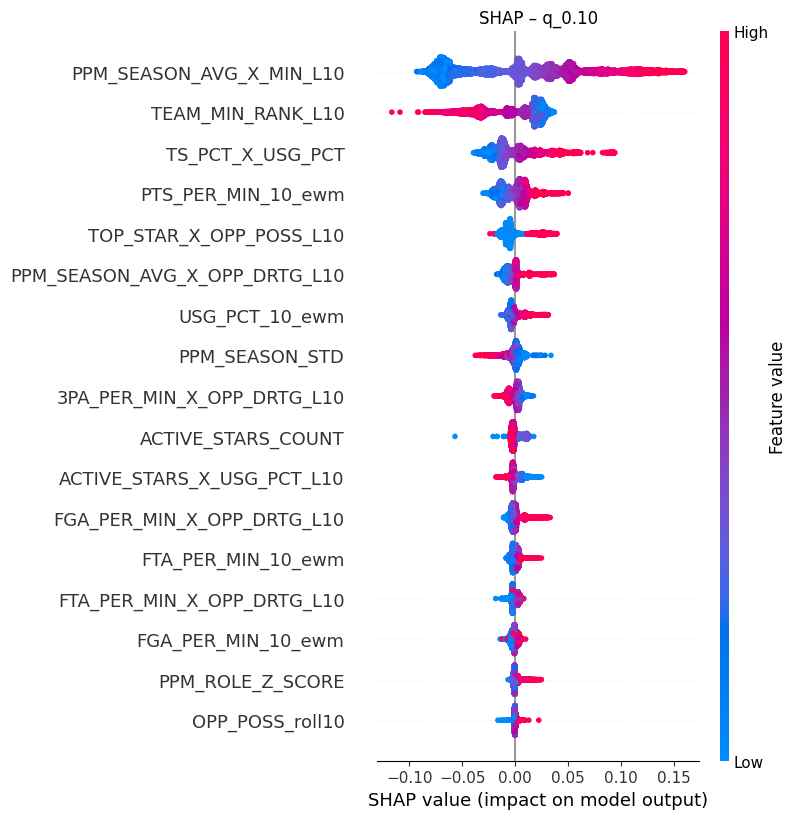


── q_0.50 ──


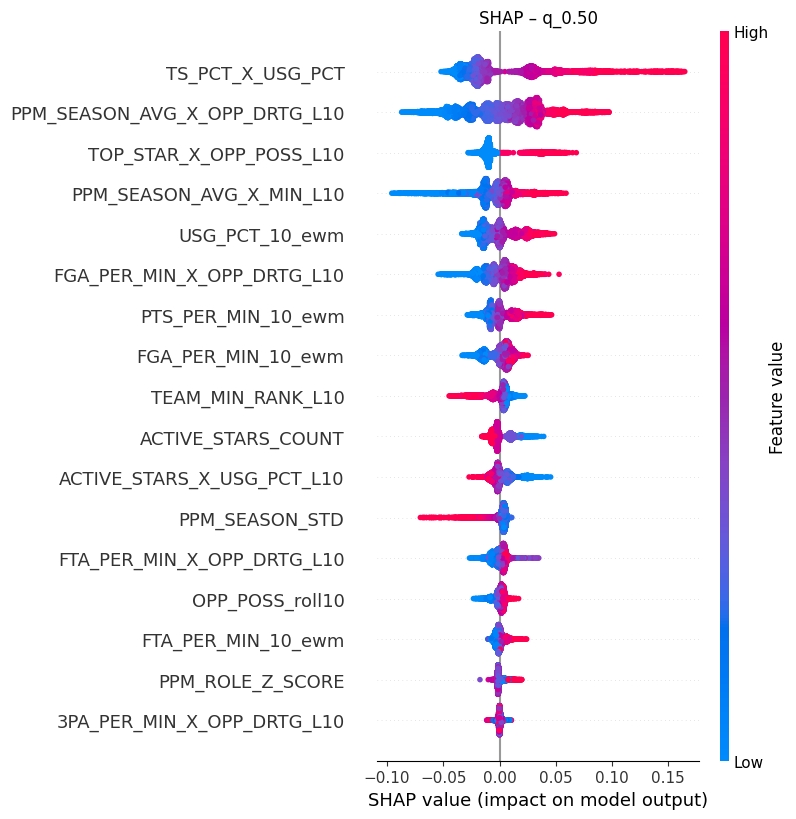


── q_0.90 ──


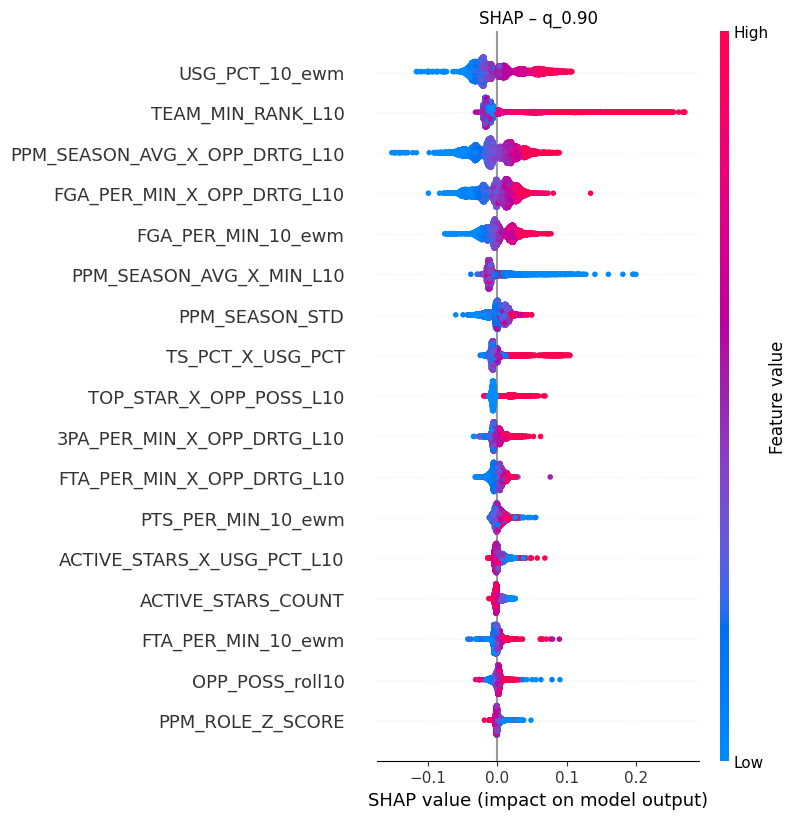

In [13]:
import shap

for q_key, model in quantile_models.items():
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_val_f)
    
    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP – {q_key}")
    plt.tight_layout()
    plt.show()

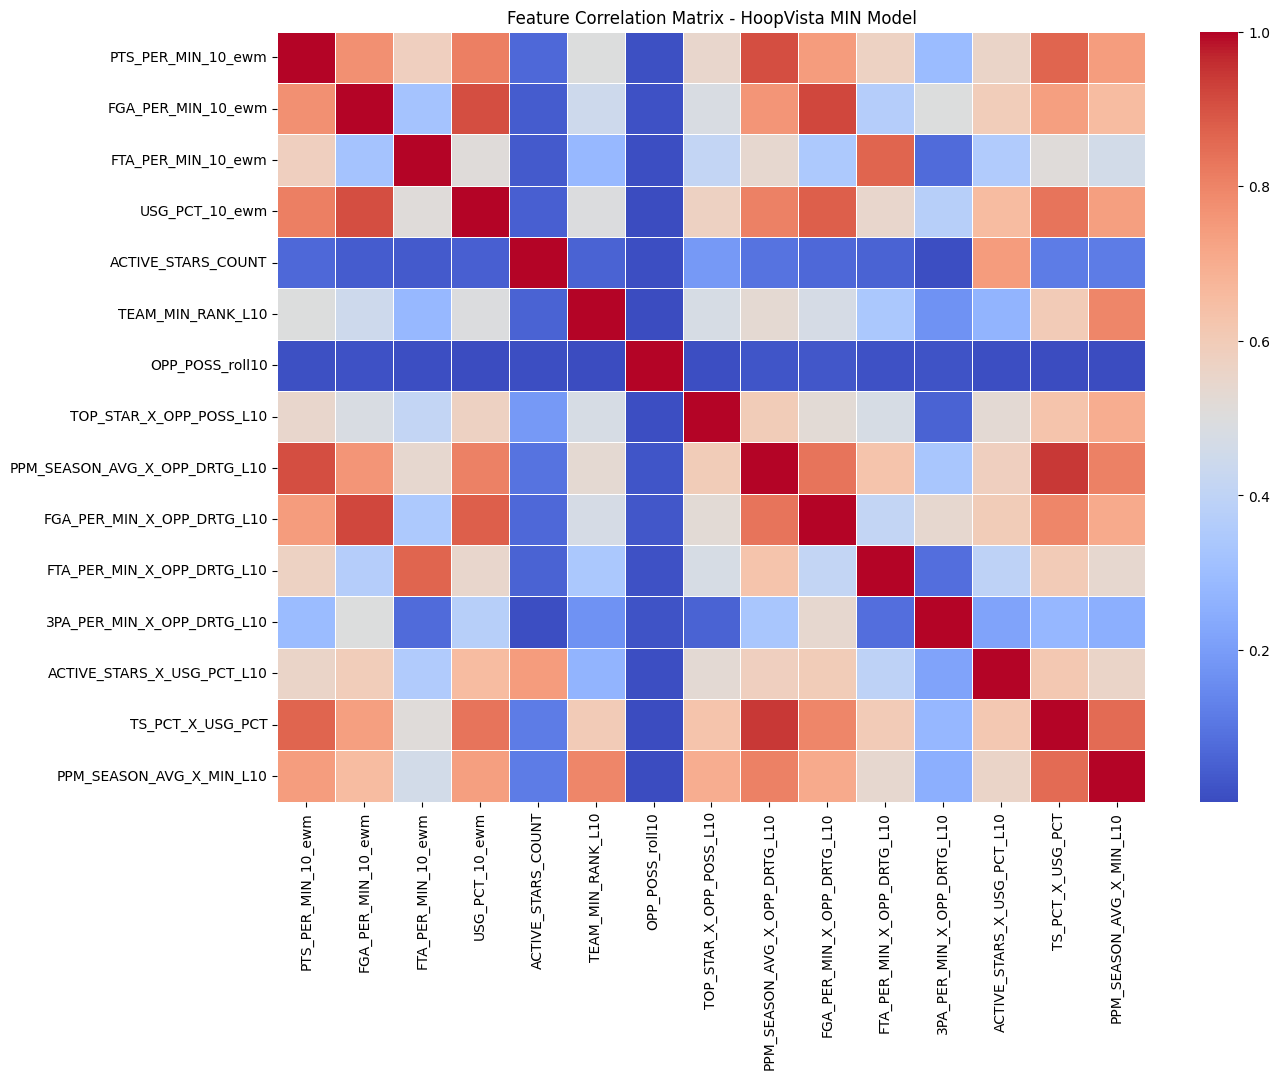

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [61]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, PPM_FEATURES)
correlated_features

In [62]:
import joblib
from pathlib import Path


bundle = {
    "quantile_models": quantile_models,
    "feature_names": PPM_FEATURES,  # or list(X_train_min.columns)
}
joblib.dump(bundle, "src/models/saved_models/ppm_quantile_xgb.joblib")

['src/models/saved_models/ppm_quantile_xgb.joblib']

## PPM MODEL + MIN MODEL Analysis

In [63]:
import joblib

min_bundle = joblib.load("src/models/saved_models/min_quantile_xgb.joblib")
min_quantile_models = min_bundle["quantile_models"]
min_feature_names = min_bundle["feature_names"]

ppm_bundle = joblib.load("src/models/saved_models/ppm_quantile_xgb.joblib")
ppm_quantile_models = ppm_bundle["quantile_models"]
ppm_feature_names = ppm_bundle["feature_names"]

In [64]:
# date = pd.Timestamp.now().normalize()  # midnight today, local tz
# current_date = date.strftime("%Y-%m-%d")

# # target_date = pd.Timestamp("2026-03-26")
# # hist = df[df["GAME_DATE"] < target_date].copy()

# lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
# lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
# lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
# names = lines_dfs['NAME'].unique()
# names

today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')
target_date = pd.Timestamp("2026-04-11")
hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260411_140648.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
names = lines_dfs['NAME'].unique()
names

array(['Bam Adebayo', 'Tyler Herro', 'Jaime Jaquez Jr', 'Davion Mitchell',
       "Kel'el Ware", 'Kawhi Leonard', 'Darius Garland',
       'Bennedict Mathurin', 'Scoot Henderson', 'Jrue Holiday',
       'Deni Avdija', 'Donovan Clingan', 'Toumani Camara',
       'Maxime Raynaud', 'Daeqwon Plowden', 'Devin Carter'], dtype=object)

In [65]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name, current_date)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        ppm_feats = ppm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        ppm_arr = np.asarray(ppm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(ppm_quantile_models["q_0.10"].predict(ppm_arr)[0])
        p50 = float(ppm_quantile_models["q_0.50"].predict(ppm_arr)[0])
        p90 = float(ppm_quantile_models["q_0.90"].predict(ppm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_PPM_Q10": p10,
            "PRED_PPM_Q50": p50,
            "PRED_PPM_Q90": p90,
            "PRED_PTS_Q10": pts10,
            "PRED_PTS_Q50": pts50,
            "PRED_PTS_Q90": pts90,
            "PRED_PTS_RANGE_10_90": pts90 - pts10,
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_PPM_Q10": np.nan,
            "PRED_PPM_Q50": np.nan,
            "PRED_PPM_Q90": np.nan,
            "PRED_PTS_Q10": np.nan,
            "PRED_PTS_Q50": np.nan,
            "PRED_PTS_Q90": np.nan,
            "PRED_PTS_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

No game found for MIA within 3 days from 2026-04-16
[SKIP] Bam Adebayo: 'float' object has no attribute 'round'
No game found for MIA within 3 days from 2026-04-16
[SKIP] Tyler Herro: 'float' object has no attribute 'round'
No game found for MIA within 3 days from 2026-04-16
[SKIP] Jaime Jaquez Jr.: 'float' object has no attribute 'round'
No game found for MIA within 3 days from 2026-04-16
[SKIP] Davion Mitchell: 'float' object has no attribute 'round'
No game found for MIA within 3 days from 2026-04-16
[SKIP] Kel'el Ware: 'float' object has no attribute 'round'
No game found for LAC within 3 days from 2026-04-16
[SKIP] Kawhi Leonard: 'float' object has no attribute 'round'
No game found for LAC within 3 days from 2026-04-16
[SKIP] Darius Garland: 'float' object has no attribute 'round'
No game found for LAC within 3 days from 2026-04-16
[SKIP] Bennedict Mathurin: 'float' object has no attribute 'round'
No game found for SAC within 3 days from 2026-04-16
[SKIP] Maxime Raynaud: 'float' 

,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_PPM_Q10,PRED_PPM_Q50,PRED_PPM_Q90,PRED_PTS_Q10,PRED_PTS_Q50,PRED_PTS_Q90,PRED_PTS_RANGE_10_90
0,Bam Adebayo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Tyler Herro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Jaime Jaquez Jr.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Davion Mitchell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kel'el Ware,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
